In [31]:
from google.colab import drive
drive.mount('/content/drive')

import os

train_path = '/content/drive/MyDrive/FlowersDataSet/flowers'
test_path = '/content/drive/MyDrive/FlowersDataSet/flowersTest'
training_names = os.listdir(train_path)
classes = os.listdir(train_path)
print(training_names)
print("Classes trouvées :", classes)
for cls in classes:
    n = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls}: {n} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['tulip', 'dandelion', 'rose', 'sunflower', 'daisy']
Classes trouvées : ['tulip', 'dandelion', 'rose', 'sunflower', 'daisy']
  tulip: 984 images
  dandelion: 1052 images
  rose: 784 images
  sunflower: 733 images
  daisy: 764 images


In [63]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

# chemin de l'image
img_path = os.path.join(train_path, "rose", os.listdir(os.path.join(train_path, "rose"))[0])

# charger sans redimensionnement
img = image.load_img(img_path)
img_array1 = image.img_to_array(img)

print(img_array1.shape)
print(img_array1.min(), img_array1.max())

(213, 320, 3)
0.0 255.0


In [33]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paramètres
img_size = (180, 180) # la taille de l'image
batch_size = 32 # le nombre des images traites en meme temps

# Générateur avec normalisation + split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20% validation
)

# Dataset d'entraînement
train_data = datagen.flow_from_directory(
    "/content/drive/MyDrive/FlowersDataSet/flowers",   # dossier principal avec sous-dossiers (classes)
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='training'
)

# Dataset validation
val_data = datagen.flow_from_directory(
    "/content/drive/MyDrive/FlowersDataSet/flowers",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation'
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [34]:
## test data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/FlowersTest",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse'
)

Found 176 images belonging to 5 classes.


In [36]:
images, labels = next(train_data)

print(images.shape)  # voir le shape(batch,size1,size,RGB/Gris) apres
img_array2=images[0] # voir la normalisation apres
print(img_array2.min(), img_array2.max())

(32, 180, 180, 3)
0.0 1.0


In [ ]:
####################   Activite 2  : Création et entraînement d’un modèle CNN personnalisé #############

In [42]:
from tensorflow.keras import models, layers

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(5, activation='softmax')) # 5 is the number of classes in our dataset


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
## complilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
## entrainement
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20 # 20 c'est le nombre d'epochs
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 918s 8s/step - accuracy: 0.4513 - loss: 1.3385 - val_accuracy: 0.5302 - val_loss: 1.1937
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.5901 - loss: 1.0437 - val_accuracy: 0.5674 - val_loss: 1.0896
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.6584 - loss: 0.8930 - val_accuracy: 0.6105 - val_loss: 1.0117
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.7533 - loss: 0.6708 - val_accuracy: 0.6140 - val_loss: 1.0456
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.8481 - loss: 0.4382 - val_accuracy: 0.6244 - val_loss: 1.1470
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9124 - loss: 0.2695 - val_accuracy: 0.6209 - val_loss: 1.5366
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.9543 - loss: 0.1417 - val_accuracy: 0.6151 - val_loss: 1.5844
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.9841 - loss: 0.0709 - val_accu

In [ ]:
##### Activite 3 : Evaluation #########

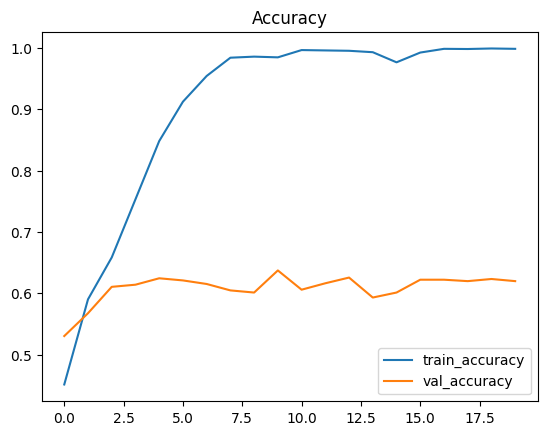

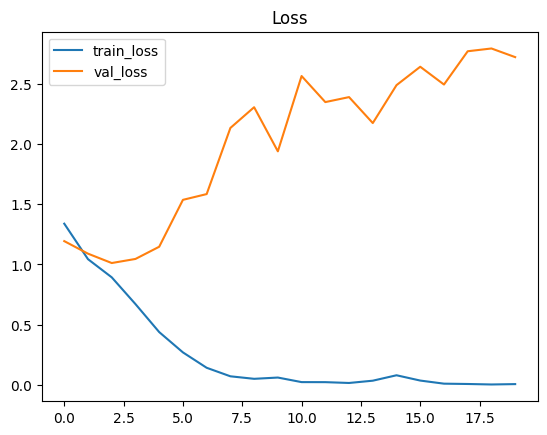

In [45]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [48]:
## testons notre model apres validation
import numpy as np
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step


In [49]:
###Classification Report   #######
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.24      0.24      0.24        38
           1       0.17      0.17      0.17        30
           2       0.20      0.27      0.23        30
           3       0.23      0.23      0.23        30
           4       0.31      0.25      0.28        48

    accuracy                           0.23       176
   macro avg       0.23      0.23      0.23       176
weighted avg       0.24      0.23      0.23       176



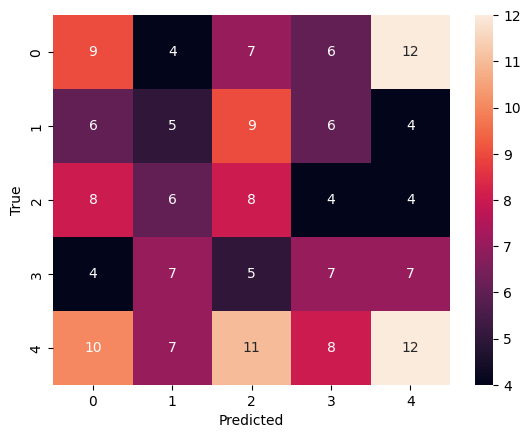

In [50]:
#### matrice de confusion #########
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

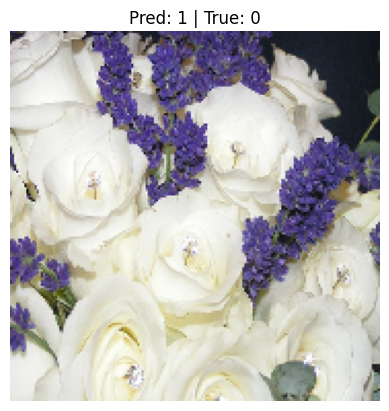

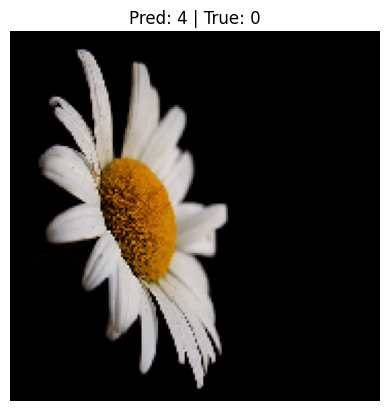

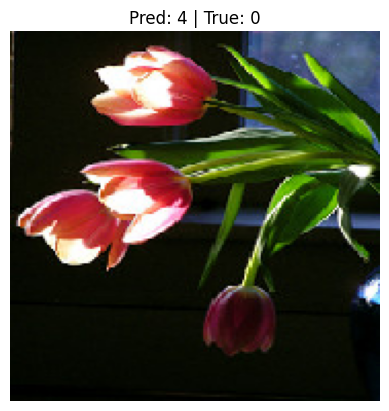

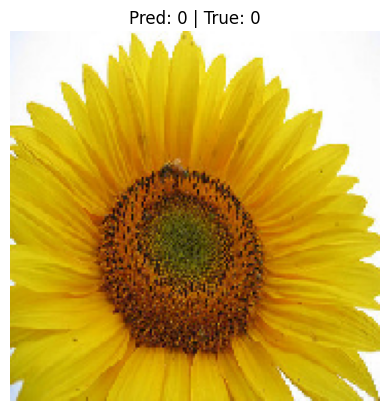

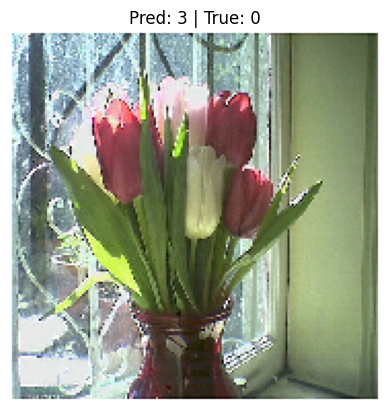

In [51]:
## afficher les erreurs ###
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(test_data[0][0][i])
    plt.title(f"Pred: {y_pred_classes[i]} | True: {y_true[i]}")
    plt.axis("off")
    plt.show()

In [ ]:
##################################
########### tester avec un exemple dans Flowers DataSet ###############

In [58]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# chemin de l'image
img_path = "/content/drive/MyDrive/FlowersTest/tulip/10791227_7168491604.jpg"

# charger l'image
img = image.load_img(img_path, target_size=(180, 180))

# convertir en tableau
img_array = image.img_to_array(img)

# normalisation
img_array = img_array / 255.0

# ajouter dimension batch
img_array = np.expand_dims(img_array, axis=0)

# prédiction
prediction = model.predict(img_array)

# classe prédite
predicted_class = np.argmax(prediction)

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: 4


In [59]:
class_names = list(train_data.class_indices.keys())

print("Classe prédite :", class_names[predicted_class])

Classe prédite : tulip


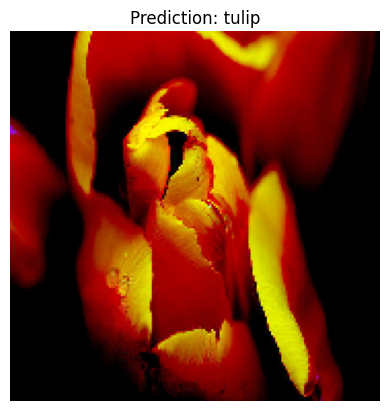

In [60]:
plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.axis("off")
plt.show()

In [61]:
print(train_data.class_indices)

{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [62]:
# Save the trained model
model_save_path = '/content/drive/MyDrive/FlowersDataSet/flower_classification_model.keras'
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/FlowersDataSet/flower_classification_model.keras
